In [2]:
import sionna.rt
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver, RadioMapSolver, Camera
import numpy as np
import matplotlib.pyplot as plt

In [3]:
scene = load_scene("scene/room.xml",merge_shapes=False)
scene.frequency = 59e9 #Hz
scene.synthetic_array = True
for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

elm__2         itu_concrete
elm__3         itu_concrete
elm__4         itu_concrete
elm__6         itu_marble
elm__8         itu_metal
elm__9         itu_metal
elm__10        itu_metal
elm__11        itu_metal
elm__12        itu_metal
elm__13        itu_metal
elm__14        itu_metal
elm__15        itu_metal
elm__16        itu_metal
elm__17        itu_metal
elm__18        itu_metal
elm__19        itu_metal
elm__20        itu_metal
elm__21        itu_metal
elm__22        itu_metal
elm__23        itu_metal
elm__24        itu_metal
elm__25        itu_metal
elm__26        itu_metal
elm__27        itu_metal
elm__28        itu_metal
elm__29        itu_metal
elm__30        itu_metal
elm__31        itu_metal
elm__32        itu_metal
elm__33        itu_metal
elm__34        itu_metal
elm__35        itu_metal
elm__36        itu_metal
elm__37        itu_metal
elm__38        itu_metal
elm__39        itu_metal
elm__40        itu_metal
elm__41        itu_metal
elm__42        itu_metal
elm__43        

In [4]:
scene.preview()

In [5]:
# Configure antenna array
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V")

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V")


In [6]:
#Create transmitter and receiver
tx = Transmitter(name="tx",
                 position=[-4, 4, 1],
                 orientation=[0.0, 0.0, 0.0],)

rx = Receiver(name="rx",
                 position=[0, 0, 1.8],
                 orientation=[0.0, 0.0, 0.0],)

scene.add(tx)
scene.add(rx)
tx.look_at(rx)

In [7]:
#Compute propagation paths
solver  = PathSolver()
paths = solver(scene,max_depth=10, samples_per_src= int(1e6))

scene.preview(paths=paths)

In [8]:
#Compute Radio Map
rmSolver = RadioMapSolver()

rm = rmSolver(scene, cell_size=(.05, .05), samples_per_tx= 100000000)
scene.preview(radio_map=rm, clip_at=15., rm_vmin=-100.)

#Other way to compute it, less details
#rm = rmSolver(scene, max_depth=10, cell_size=[0.05, 0.05])
#scene.preview(radio_map=rm)

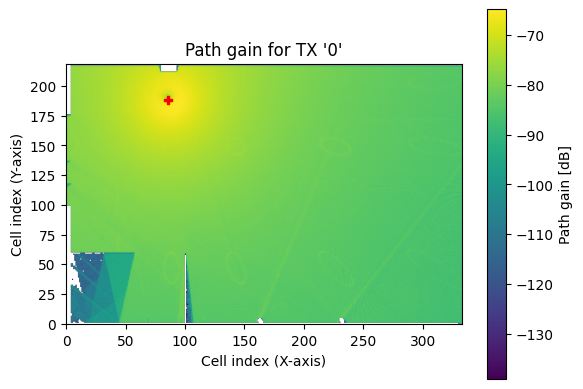

In [9]:
rmPlot = rm.show(tx=0)

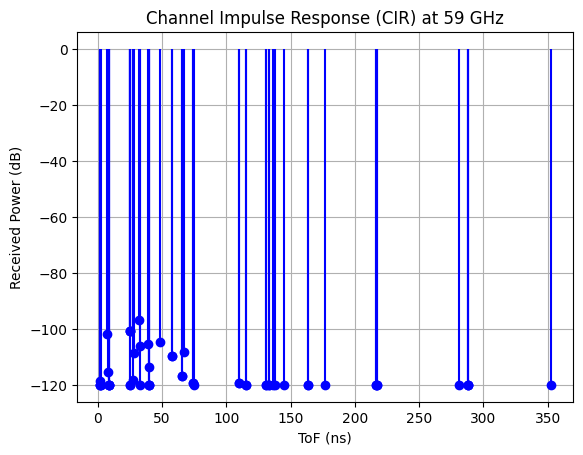

All captured paths: 59
Path 1, Delay = 7.14 ns, Power = -101.91 dB
Path 2, Delay = 27.61 ns, Power = -118.41 dB
Path 3, Delay = 25.28 ns, Power = -100.70 dB
Path 4, Delay = 25.28 ns, Power = -100.67 dB
Path 5, Delay = 31.96 ns, Power = -96.93 dB
Path 6, Delay = 39.10 ns, Power = -105.23 dB
Path 7, Delay = 57.94 ns, Power = -109.77 dB
Path 8, Delay = 25.28 ns, Power = -100.67 dB
Path 9, Delay = 65.74 ns, Power = -116.75 dB
Path 10, Delay = 66.92 ns, Power = -108.39 dB
Path 11, Delay = 74.22 ns, Power = -119.37 dB
Path 12, Delay = 74.22 ns, Power = -119.37 dB
Path 13, Delay = 65.74 ns, Power = -116.75 dB
Path 14, Delay = 109.76 ns, Power = -119.45 dB
Path 15, Delay = 109.76 ns, Power = -119.46 dB
Path 16, Delay = 115.30 ns, Power = -119.99 dB
Path 17, Delay = 57.94 ns, Power = -109.76 dB
Path 18, Delay = 48.49 ns, Power = -104.65 dB
Path 19, Delay = 130.79 ns, Power = -120.00 dB
Path 20, Delay = 137.62 ns, Power = -119.96 dB
Path 21, Delay = 136.09 ns, Power = -119.99 dB
Path 22, Delay =

In [10]:
# Extract CIR, complex amplitudes and time delay
a, tau = paths.cir()

amplitudesFix = a[0][0].numpy()
delaysFix = tau[0][0].numpy()

amplitudes = np.squeeze(amplitudesFix)
delays = np.squeeze(delaysFix)

validPaths = delays > 0
validDelays = delays[validPaths]
validAmplitudes = amplitudes[validPaths]

dBPower = 10*np.log10(np.abs(validAmplitudes)**2 + 1e-12)
delayInNs = validDelays*1e9

#Power Delay Profile
plt.figure()
plt.stem(delayInNs, dBPower, basefmt=" ", linefmt="blue", markerfmt="bo")
plt.title("Channel Impulse Response (CIR) at 59 GHz")
plt.xlabel("ToF (ns)")
plt.ylabel("Received Power (dB)")
plt.grid(True)
plt.show()

print(f"All captured paths: {len(validPaths)}")
for i in range(len(validDelays)):
    print(f"Path {i+1}, Delay = {delayInNs[i]:.2f} ns, Power = {dBPower[i]:.2f} dB")